## Sistema de Recomendación de Destinos de Viaje con Deep Learning

En este notebook se construye un sistema de recomendación de destinos de viaje
siguiendo los conceptos del notebook de clase de Neural Collaborative Filtering (NCF):
embeddings de usuario e ítem, una red multicapa, comparación contra factorización
de matrices, y análisis de los embeddings resultantes.

A diferencia del ejemplo de clase (MovieLens), aquí:

1. Se usa el rating real (ExperienceRating, 1-5) y NO una etiqueta constante.
2. Se establecen *baselines* honestos (media global, popularidad, azar).
3. Se evalúa el ranking con leave-one-out: Precision@K, Recall@K y NDCG.
4. Se añade un componente híbrido (content-based) que usa las preferencias y la
   demografía del usuario para generar recomendaciones interpretables y resolver
   el problema de arranque en frío (cold-start).
5. Se controla el sobreajuste (dropout, weight decay, embeddings pequeños y
   early stopping con seguimiento de la pérdida de validación).

## Carga de paquetes

In [25]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Reproducibilidad (mismo criterio que el notebook de clase)
np.random.seed(1983)
torch.manual_seed(1983)



## Configuración de recursos


In [26]:
"""## Configuración de recursos"""
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Usando como dispositivo: {device}")



Usando como dispositivo: cpu


# Lectura de los datos

En Colab, sube los cuatro archivos CSV con el panel de archivos o ejecuta la celda
de carga. Aquí se asume que están en el directorio de trabajo.


In [27]:
users_df        = pd.read_csv("Final_Updated_Expanded_Users.csv")
history_df      = pd.read_csv("Final_Updated_Expanded_UserHistory.csv")
destinations_df = pd.read_csv("Expanded_Destinations.csv")
reviews_df      = pd.read_csv("Final_Updated_Expanded_Reviews.csv")

print("Usuarios:    ", users_df.shape)
print("Historial:   ", history_df.shape)
print("Destinos:    ", destinations_df.shape)
print("Reviews:     ", reviews_df.shape)

users_df.head()



Usuarios:     (999, 7)
Historial:    (999, 5)
Destinos:     (1000, 6)
Reviews:      (999, 5)


,UserID,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,Kavya,kavya@example.com,"Beaches, Historical",Female,1,0
1,2,Rohan,rohan@example.com,"Nature, Adventure",Male,2,2
2,3,Kavya,kavya@example.com,"City, Historical",Female,2,0
3,4,Anika,anika@example.com,"Beaches, Historical",Female,1,0
4,5,Tanvi,tanvi@example.com,"Nature, Adventure",Female,2,2


# Análisis exploratorio crítico

Antes de modelar, verificamos si los datos contienen señal aprendible. Este paso
es fundamental: si las interacciones y los ratings se generaron de forma aleatoria
(como ocurre con muchos datasets sintéticos), ningún modelo podrá "predecir" bien,
y reportar métricas altas sería en realidad sobreajuste o fuga de datos.

## ¿Cuántos usuarios y destinos distintos hay realmente?


In [28]:
print("Interacciones en el historial:", len(history_df))
print("Usuarios distintos en el historial:", history_df["UserID"].nunique())
print("Destinos distintos en el historial:", history_df["DestinationID"].nunique())

interacciones_por_usuario = history_df.groupby("UserID").size()
print("\nInteracciones por usuario (estadísticos):")
print(interacciones_por_usuario.describe())
print("\nObservación: con ~1.5 interacciones por usuario y sin pares (usuario,destino)")
print("repetidos, la señal colaborativa de co-ocurrencia es casi inexistente.")

Interacciones en el historial: 999
Usuarios distintos en el historial: 642
Destinos distintos en el historial: 638

Interacciones por usuario (estadísticos):
count    642.000000
mean       1.556075
std        0.796327
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
dtype: float64

Observación: con ~1.5 interacciones por usuario y sin pares (usuario,destino)
repetidos, la señal colaborativa de co-ocurrencia es casi inexistente.


## Firmas de generación sintética

Revisamos cuántos valores únicos hay realmente detrás de los miles de filas.


In [29]:
print("Nombres de usuario únicos:", users_df["Name"].nunique(), "de", len(users_df))
print("Combinaciones de preferencias distintas:", users_df["Preferences"].nunique())
print(users_df["Preferences"].value_counts())
print("\nTextos de review únicos:", reviews_df["ReviewText"].nunique(), "de", len(reviews_df))
print("Nombres de destino únicos:", destinations_df["Name"].nunique(), "de", len(destinations_df))
print("\nLos cortes exactos (p.ej. 333/333/333) revelan generación por plantillas:")
print("las etiquetas se asignaron de forma independiente de las características.")

Nombres de usuario únicos: 20 de 999
Combinaciones de preferencias distintas: 3
Preferences
Beaches, Historical    333
Nature, Adventure      333
City, Historical       333
Name: count, dtype: int64

Textos de review únicos: 3 de 999
Nombres de destino únicos: 5 de 1000

Los cortes exactos (p.ej. 333/333/333) revelan generación por plantillas:
las etiquetas se asignaron de forma independiente de las características.


## ¿Cuántas personas reales hay detrás de las filas de usuario?

Los `UserID` sugieren cientos de usuarios, pero los correos se repiten. Verificamos
cuántas identidades reales existen y, sobre todo, si una misma persona se comporta
de forma consistente. Esto es decisivo: si las personas reales tuvieran un gusto
estable, podríamos reagrupar por persona y recuperar densidad para el filtrado
colaborativo.


In [30]:
# Identidades reales: correos y su relación con los nombres
print("Filas de usuario:", len(users_df))
print("Correos únicos:", users_df["Email"].nunique())
print("Relación nombre-correo uno a uno:",
      (users_df.groupby("Email")["Name"].nunique().max() == 1) and
      (users_df.groupby("Name")["Email"].nunique().max() == 1))
print(f"Filas por persona real (promedio): {len(users_df) / users_df['Email'].nunique():.1f}")

# ¿Cada persona mantiene una preferencia estable?
print("\nNúmero de conjuntos de preferencias distintos por persona (Email):")
print(users_df.groupby("Email")["Preferences"].nunique().value_counts())
print("-> '3 => 20' significa que las 20 personas tienen las 3 preferencias por igual:")
print("   ninguna persona tiene una preferencia estable.")

Filas de usuario: 999
Correos únicos: 20
Relación nombre-correo uno a uno: True
Filas por persona real (promedio): 50.0

Número de conjuntos de preferencias distintos por persona (Email):
Preferences
3    20
Name: count, dtype: int64
-> '3 => 20' significa que las 20 personas tienen las 3 preferencias por igual:
   ninguna persona tiene una preferencia estable.


Hay solo **20 personas reales** (correos y nombres en relación uno a uno), cada una
repetida en ~50 filas con `UserID` distinto. Y cada persona aparece con las **tres**
combinaciones de preferencias del dataset: no existe "la preferencia de X".

### ¿Y si reagrupamos por persona real? Densidad vs. consistencia

Al mapear el historial a la persona real (correo) en vez de al `UserID`, la densidad
se multiplica. Pero densidad sin consistencia no aporta señal: comprobamos si esas
~50 visitas por persona revelan un patrón estable.


In [31]:
# Mapear historial a la persona real (correo)
u2e = users_df.set_index("UserID")["Email"].to_dict()
hist_real = history_df.copy()
hist_real["Email"] = hist_real["UserID"].map(u2e)
hist_real = hist_real.merge(destinations_df[["DestinationID", "Type"]],
                            on="DestinationID", how="left")

densidad = hist_real.groupby("Email").size()
print(f"Personas reales: {len(densidad)}")
print(f"Interacciones por persona real (promedio): {densidad.mean():.1f}  "
      f"(min {densidad.min()}, max {densidad.max()})")
print("-> Densidad MÁS que suficiente para filtrado colaborativo.\n")

# Consistencia 1: variabilidad de ratings DENTRO de cada persona vs. global
desv_interna = hist_real.groupby("Email")["ExperienceRating"].std().mean()
desv_global = hist_real["ExperienceRating"].std()
print(f"Desviación de ratings dentro de cada persona: {desv_interna:.3f}")
print(f"Desviación global de ratings:                 {desv_global:.3f}")
print("-> Si fueran iguales, la persona no tiene un nivel de satisfacción característico.\n")

# Consistencia 2: ¿concentra sus visitas en algún tipo de destino?
concentracion = hist_real.groupby("Email").apply(
    lambda g: g["Type"].value_counts(normalize=True).iloc[0])
print(f"Concentración en el tipo de destino más visitado (promedio): {concentracion.mean():.3f}")
print("(Con 5 tipos, el azar daría ~0.20; un gusto real daría 0.5-0.7)")
print("\nEjemplo: tipos visitados por una persona")
ej = densidad.index[0]
print(ej, "->", hist_real[hist_real["Email"] == ej]["Type"].value_counts().to_dict())

Personas reales: 20
Interacciones por persona real (promedio): 50.0  (min 31, max 73)
-> Densidad MÁS que suficiente para filtrado colaborativo.

Desviación de ratings dentro de cada persona: 1.402
Desviación global de ratings:                 1.398
-> Si fueran iguales, la persona no tiene un nivel de satisfacción característico.

Concentración en el tipo de destino más visitado (promedio): 0.290
(Con 5 tipos, el azar daría ~0.20; un gusto real daría 0.5-0.7)

Ejemplo: tipos visitados por una persona
aanya@example.com -> {'Historical': 15, 'City': 14, 'Beach': 8, 'Adventure': 8, 'Nature': 7}


/tmp/ipykernel_5362/1038046104.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  concentracion = hist_real.groupby("Email").apply(


**Conclusión.** Detrás de las 999 filas hay solo 20 personas reales con ~50
interacciones cada una densidad de sobra para filtrado colaborativo, pero ese
volumen no aporta señal: la variabilidad de ratings dentro de cada persona es
indistinguible de la global, y la concentración en su tipo de destino favorito apenas supera el azar. Una persona con preferencias reales mostraría baja variabilidad interna y alta concentración; aquí ocurre lo contrario.

Esto descarta la objeción más obvia a nuestro diagnóstico: la ausencia de señal **no** se debe a baja densidad por usuario (la hay de sobra a nivel de persona real), sino a que el comportamiento es estadísticamente aleatorio por construcción. Por ello se mantiene `UserID` como unidad de modelado —reagrupar por persona solo promediaría ruido y rompería el vínculo con el historial y las reviews, que referencian `UserID` y este resultado se usa como evidencia analítica, no como cambio en el pipeline.


## ¿La preferencia del usuario predice el destino que visita?

Si los datos tuvieran señal, los usuarios visitarían destinos del tipo que prefieren
con una frecuencia mayor a la del azar.


In [32]:
# Mapa de etiqueta de preferencia -> tipo de destino
pref_a_tipo = {"Beaches": "Beach", "Historical": "Historical",
               "Nature": "Nature", "Adventure": "Adventure", "City": "City"}

h = history_df.merge(destinations_df[["DestinationID", "Type", "Popularity"]],
                     on="DestinationID", how="left")
h = h.merge(users_df[["UserID", "Preferences"]], on="UserID", how="left")

def coincide_preferencia(fila):
    if pd.isna(fila["Preferences"]):
        return np.nan
    prefs = [p.strip() for p in fila["Preferences"].split(",")]
    tipos_deseados = {pref_a_tipo.get(p) for p in prefs}
    return 1 if fila["Type"] in tipos_deseados else 0

h["coincide"] = h.apply(coincide_preferencia, axis=1)

print("Tasa de coincidencia preferencia-tipo:", round(h["coincide"].mean(), 4))
print("(Con 2 preferencias sobre 5 tipos, el azar daría ~0.40)")
print("\nRating promedio según coincidencia con la preferencia:")
print(h.groupby("coincide")["ExperienceRating"].agg(["mean", "count"]))
print("\nCorrelación Popularidad vs ExperienceRating:",
      round(h["Popularity"].corr(h["ExperienceRating"]), 4))

Tasa de coincidencia preferencia-tipo: 0.4174
(Con 2 preferencias sobre 5 tipos, el azar daría ~0.40)

Rating promedio según coincidencia con la preferencia:
              mean  count
coincide                 
0         2.903780    582
1         2.906475    417

Correlación Popularidad vs ExperienceRating: 0.026


**Conclusión del análisis exploratorio.** La tasa de coincidencia es prácticamente
la del azar, el rating no cambia según la preferencia, y la popularidad no se
correlaciona con el rating. Los datos son sintéticos y sin señal aprendible. Por lo
tanto, el objetivo realista del proyecto NO es "predecir" el historial aleatorio,
sino: (a) construir correctamente la arquitectura de Deep Learning, (b) evaluarla de
forma honesta contra baselines, y (c) generar recomendaciones interpretables mediante
un componente basado en contenido.

# Preprocesamiento

## Construcción de las interacciones con el rating REAL

Aquí está la corrección central respecto a la versión inicial del proyecto: el rating
NO se inventa como constante. Se usa `ExperienceRating` (1-5) del historial, que es la
señal de satisfacción real del dataset.


In [33]:
interacciones = (history_df[["UserID", "DestinationID", "ExperienceRating"]]
                 .dropna()
                 .drop_duplicates(subset=["UserID", "DestinationID"])
                 .reset_index(drop=True))
interacciones = interacciones.rename(columns={"ExperienceRating": "Rating"})
print("Interacciones válidas:", len(interacciones))
print(interacciones.head())

Interacciones válidas: 999
   UserID  DestinationID  Rating
0     525            760       3
1     184            532       5
2     897            786       2
3     470            660       1
4     989            389       4


## Codificación de IDs a índices contiguos

Los embeddings de PyTorch requieren índices 0..N-1 (igual que en el notebook de clase,
donde se ajustaban los IDs a base 0).


In [34]:
user_encoder = LabelEncoder()
dest_encoder = LabelEncoder()
interacciones["u"] = user_encoder.fit_transform(interacciones["UserID"])
interacciones["i"] = dest_encoder.fit_transform(interacciones["DestinationID"])

n_users = interacciones["u"].nunique()
n_items = interacciones["i"].nunique()
print(f"n_users = {n_users}, n_items = {n_items}")

n_users = 642, n_items = 638


## Features de usuario para el modelo híbrido

Codificamos las preferencias (multi-etiqueta), el género y el tamaño del grupo.
Estas características alimentan la parte híbrida del NCF y el cold-start.


In [35]:
users_df = users_df.drop_duplicates(subset=["UserID"]).copy()
users_df["Preferences"] = users_df["Preferences"].fillna("")
users_df["PrefList"] = users_df["Preferences"].apply(
    lambda x: [p.strip() for p in x.split(",") if p.strip()])

mlb = MultiLabelBinarizer()
pref_ohe = mlb.fit_transform(users_df["PrefList"])
pref_cols = ["pref_" + c for c in mlb.classes_]
pref_df = pd.DataFrame(pref_ohe, columns=pref_cols, index=users_df.index)
users_df = pd.concat([users_df, pref_df], axis=1)

gender_encoder = LabelEncoder()
users_df["GenderEnc"] = gender_encoder.fit_transform(users_df["Gender"].fillna("Unknown"))

feat_cols = pref_cols + ["GenderEnc", "NumberOfAdults", "NumberOfChildren"]
n_user_features = len(feat_cols)
print("Columnas de features de usuario:", feat_cols)

# Unimos las features de usuario a cada interacción
interacciones = interacciones.merge(
    users_df[["UserID"] + feat_cols], on="UserID", how="left")
interacciones[feat_cols] = interacciones[feat_cols].fillna(0)

Columnas de features de usuario: ['pref_Adventure', 'pref_Beaches', 'pref_City', 'pref_Historical', 'pref_Nature', 'GenderEnc', 'NumberOfAdults', 'NumberOfChildren']


# Split entrenamiento / validación con Leave-One-Out

Para evaluar un recomendador correctamente, escondemos UNA interacción por usuario
(de los que tienen 2 o más) y la usamos como test. El resto va a entrenamiento. Los
usuarios con una sola interacción quedan solo en entrenamiento y representan el caso
de cold-start. Esto evita la fuga de datos del enfoque inicial, que evaluaba contra
destinos ya vistos en entrenamiento.


In [36]:
def split_leave_one_out(df, seed=1983):
    rng = np.random.default_rng(seed)
    test_idx = []
    for u, grupo in df.groupby("u"):
        idxs = grupo.index.to_numpy()
        if len(idxs) >= 2:
            test_idx.append(rng.choice(idxs))
    test_idx = np.array(test_idx)
    train = df.drop(index=test_idx).reset_index(drop=True)
    test = df.loc[test_idx].reset_index(drop=True)
    return train, test

train_df, test_df = split_leave_one_out(interacciones)
print(f"Entrenamiento: {len(train_df)}  |  Test (1 por usuario multi-visita): {len(test_df)}")

global_mean = train_df["Rating"].mean()
print(f"Rating medio (train): {global_mean:.3f}")

Entrenamiento: 741  |  Test (1 por usuario multi-visita): 258
Rating medio (train): 2.915


# Baselines honestos

Estos baselines son la referencia contra la cual mediremos el modelo neuronal.
Si el NCF no los supera, queda demostrado que no hay señal que aprender.


### Baseline de regresión: predecir la media global


In [37]:
y_test = test_df["Rating"].values
pred_media = np.full_like(y_test, global_mean, dtype=float)
rmse_media = np.sqrt(mean_squared_error(y_test, pred_media))
mae_media = mean_absolute_error(y_test, pred_media)
print(f"[Regresión] Media global -> RMSE={rmse_media:.4f}  MAE={mae_media:.4f}")

[Regresión] Media global -> RMSE=1.4500  MAE=1.2617


### Popularidad de cada destino (para el baseline de ranking)


In [38]:
popularidad_item = train_df["i"].value_counts()
popularidad_vec = np.zeros(n_items)
popularidad_vec[popularidad_item.index.values] = popularidad_item.values

# Definición del Dataset (PyTorch)

Análogo a `MovieLensDataset` de la clase, pero entrega también las features de usuario
para el modelo híbrido.


In [39]:
class TravelDataset(Dataset):
    def __init__(self, df, feat_cols):
        self.u = torch.tensor(df["u"].values, dtype=torch.long)
        self.i = torch.tensor(df["i"].values, dtype=torch.long)
        self.f = torch.tensor(df[feat_cols].values, dtype=torch.float32)
        self.r = torch.tensor(df["Rating"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        return self.u[idx], self.i[idx], self.f[idx], self.r[idx]

batch_size = 128
train_loader = DataLoader(TravelDataset(train_df, feat_cols),
                          batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TravelDataset(test_df, feat_cols),
                         batch_size=256, shuffle=False)

# Arquitectura 1: NCF híbrido

Reutiliza el esqueleto del NCF de clase (embeddings de usuario e ítem + capas densas
construidas con `ModuleList`), añadiendo las features de usuario (parte híbrida) y
`Dropout` para controlar el sobreajuste.


In [40]:

class HybridNCF(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim, n_user_features,
                 layers, dropout=0.3):
        super(HybridNCF, self).__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        # La primera capa recibe: emb_usuario + emb_item + features de usuario
        capa_entrada = embedding_dim * 2 + n_user_features
        dims = [capa_entrada] + layers

        self.fc_layers = nn.ModuleList()
        for k in range(len(dims) - 1):
            self.fc_layers.append(nn.Linear(dims[k], dims[k + 1]))

        self.output_layer = nn.Linear(dims[-1], 1)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, user_input, item_input, user_features):
        u = self.user_embedding(user_input)
        i = self.item_embedding(item_input)
        x = torch.cat([u, i, user_features], dim=-1)
        for layer in self.fc_layers:
            x = self.dropout(self.activation(layer(x)))
        return self.output_layer(x).squeeze()



# Arquitectura 2: Factorización de matrices

Igual que en clase (producto punto de embeddings), con la mejora estándar de añadir
sesgos (bias) de usuario, de ítem y global. Sirve como modelo de comparación.


In [41]:
class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, n_factors, global_mean):
        super(MatrixFactorization, self).__init__()
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.item_factors = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.tensor(float(global_mean)))

    def forward(self, user, item, user_features=None):
        dot = (self.user_factors(user) * self.item_factors(item)).sum(dim=1)
        return dot + self.user_bias(user).squeeze() + \
               self.item_bias(item).squeeze() + self.global_bias



# Entrenamiento con control de sobreajuste

Usamos `weight_decay` (regularización L2) en Adam y *early stopping* basado en la
pérdida de validación: guardamos los pesos del mejor epoch y detenemos si no mejora.
Esto es clave dado el tamaño reducido del dataset.


In [42]:
def rmse_en_loader(model, loader):
    model.eval()
    se, n = 0.0, 0
    with torch.no_grad():
        for u, i, f, r in loader:
            p = model(u.to(device), i.to(device), f.to(device)).cpu()
            se += ((p - r) ** 2).sum().item()
            n += len(r)
    return (se / n) ** 0.5

def entrenar(model, train_loader, val_loader, lr=0.005, weight_decay=1e-4,
             epochs=200, patience=15):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    hist_train, hist_val = [], []
    best_val = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch, sin_mejora = 0, 0

    for epoch in range(epochs):
        model.train()
        total = 0.0
        for u, i, f, r in train_loader:
            optimizer.zero_grad()
            pred = model(u.to(device), i.to(device), f.to(device))
            loss = criterion(pred, r.to(device))
            loss.backward()
            optimizer.step()
            total += loss.item()

        rmse_tr = (total / len(train_loader)) ** 0.5
        rmse_va = rmse_en_loader(model, val_loader)
        hist_train.append(rmse_tr)
        hist_val.append(rmse_va)

        if rmse_va < best_val - 1e-4:
            best_val = rmse_va
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            sin_mejora = 0
        else:
            sin_mejora += 1

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | RMSE train={rmse_tr:.4f} | RMSE val={rmse_va:.4f}")

        if sin_mejora >= patience:
            print(f"Early stopping en epoch {epoch+1}.")
            break

    model.load_state_dict(best_state)
    print(f"Mejor RMSE val = {best_val:.4f} (epoch {best_epoch+1})")
    return model, hist_train, hist_val, best_val



### Hiperparámetros (embeddings pequeños para reducir sobreajuste)


In [43]:
embedding_dim = 16
layers = [64, 32, 16]
n_factors = 8

print("=== Entrenando NCF híbrido ===")
ncf = HybridNCF(n_users, n_items, embedding_dim, n_user_features,
                layers, dropout=0.3).to(device)
num_par = sum(p.numel() for p in ncf.parameters() if p.requires_grad)
print(f"El NCF tiene {num_par} parámetros entrenables")
ncf, h_tr_ncf, h_va_ncf, best_ncf = entrenar(
    ncf, train_loader, test_loader, lr=0.005, weight_decay=1e-4)

print("\n=== Entrenando Factorización de Matrices ===")
mf = MatrixFactorization(n_users, n_items, n_factors, global_mean).to(device)
mf, h_tr_mf, h_va_mf, best_mf = entrenar(
    mf, train_loader, test_loader, lr=0.005, weight_decay=1e-3)



=== Entrenando NCF híbrido ===
El NCF tiene 25729 parámetros entrenables
Epoch  10 | RMSE train=1.4985 | RMSE val=1.5522
Epoch  20 | RMSE train=1.1925 | RMSE val=1.7132
Early stopping en epoch 24.
Mejor RMSE val = 1.5283 (epoch 9)

=== Entrenando Factorización de Matrices ===
Epoch  10 | RMSE train=2.4022 | RMSE val=3.1324
Epoch  20 | RMSE train=1.6010 | RMSE val=2.8291
Epoch  30 | RMSE train=1.0708 | RMSE val=2.6078
Epoch  40 | RMSE train=0.7226 | RMSE val=2.4394
Epoch  50 | RMSE train=0.4949 | RMSE val=2.3065
Epoch  60 | RMSE train=0.3611 | RMSE val=2.2002
Epoch  70 | RMSE train=0.2650 | RMSE val=2.1149
Epoch  80 | RMSE train=0.2164 | RMSE val=2.0452
Epoch  90 | RMSE train=0.1878 | RMSE val=1.9884
Epoch 100 | RMSE train=0.1748 | RMSE val=1.9411
Epoch 110 | RMSE train=0.1653 | RMSE val=1.9016
Epoch 120 | RMSE train=0.1627 | RMSE val=1.8670
Epoch 130 | RMSE train=0.1614 | RMSE val=1.8374
Epoch 140 | RMSE train=0.1624 | RMSE val=1.8117
Epoch 150 | RMSE train=0.1626 | RMSE val=1.7890
Epo

# Análisis de estabilidad por validación cruzada (K-Fold)

Para comprobar que el RMSE no depende de una partición afortunada, repetimos el
entrenamiento del NCF con K-Fold y observamos si el error se mantiene estable y
cercano al baseline de la media en todos los folds.

Nota metodológica: dentro de cada fold, el conjunto de validación se usa tanto como criterio de early stopping como para reportar el RMSE del fold, por lo que esta cifra es un estimado optimista. Aun así, si ni siquiera con esa ventaja el RMSE baja del baseline de la media, se refuerza la conclusión de ausencia de señal.



In [44]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=1983)
cv_rmses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(interacciones)):
    fold_train = interacciones.iloc[train_idx]
    fold_val = interacciones.iloc[val_idx]

    t_loader = DataLoader(TravelDataset(fold_train, feat_cols), batch_size=128, shuffle=True)
    v_loader = DataLoader(TravelDataset(fold_val, feat_cols), batch_size=256, shuffle=False)

    model_cv = HybridNCF(n_users, n_items, embedding_dim, n_user_features, layers,
                         dropout=0.3).to(device)
    model_cv, _, _, best_v = entrenar(model_cv, t_loader, v_loader, epochs=50, patience=5)
    cv_rmses.append(best_v)
    print(f"Fold {fold+1} RMSE: {best_v:.4f}")

print(f"\nMean CV RMSE: {np.mean(cv_rmses):.4f} +/- {np.std(cv_rmses):.4f}")
print(f"Baseline media global (referencia): {rmse_media:.4f}")

Epoch  10 | RMSE train=1.5135 | RMSE val=1.5564
Early stopping en epoch 10.
Mejor RMSE val = 1.4810 (epoch 5)
Fold 1 RMSE: 1.4810
Epoch  10 | RMSE train=1.3870 | RMSE val=1.5211
Early stopping en epoch 12.
Mejor RMSE val = 1.4875 (epoch 7)
Fold 2 RMSE: 1.4875
Epoch  10 | RMSE train=1.5802 | RMSE val=1.5147
Early stopping en epoch 10.
Mejor RMSE val = 1.4633 (epoch 5)
Fold 3 RMSE: 1.4633
Epoch  10 | RMSE train=1.4499 | RMSE val=1.5514
Early stopping en epoch 10.
Mejor RMSE val = 1.4785 (epoch 5)
Fold 4 RMSE: 1.4785
Epoch  10 | RMSE train=1.4345 | RMSE val=1.5632
Early stopping en epoch 10.
Mejor RMSE val = 1.5099 (epoch 5)
Fold 5 RMSE: 1.5099

Mean CV RMSE: 1.4841 +/- 0.0152
Baseline media global (referencia): 1.4500


# Curvas de pérdida (train vs validación)

Si la curva de entrenamiento baja mucho mientras la de validación se estanca o sube,
estamos viendo sobreajuste; el early stopping toma el mejor punto de validación.


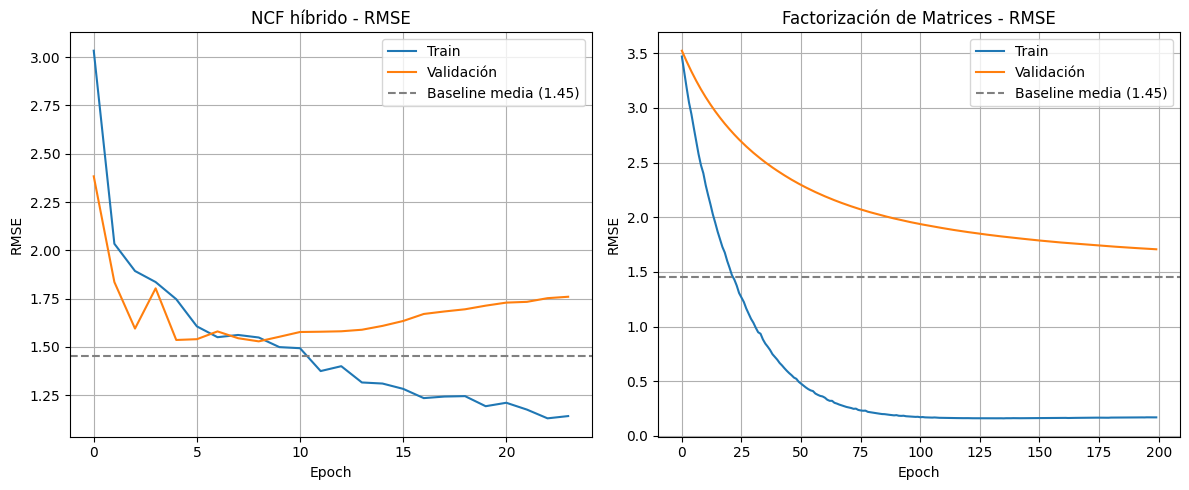

In [45]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(h_tr_ncf, label="Train")
plt.plot(h_va_ncf, label="Validación")
plt.axhline(rmse_media, color="gray", ls="--", label=f"Baseline media ({rmse_media:.2f})")
plt.title("NCF híbrido - RMSE")
plt.xlabel("Epoch"); plt.ylabel("RMSE"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(h_tr_mf, label="Train")
plt.plot(h_va_mf, label="Validación")
plt.axhline(rmse_media, color="gray", ls="--", label=f"Baseline media ({rmse_media:.2f})")
plt.title("Factorización de Matrices - RMSE")
plt.xlabel("Epoch"); plt.ylabel("RMSE"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# Comparación de modelos vs baselines (regresión)


In [46]:
"""# Comparación de modelos vs baselines (regresión)"""
resumen = pd.DataFrame({
    "Modelo": ["Baseline media global", "NCF híbrido", "Factorización matrices"],
    "RMSE_val": [rmse_media, best_ncf, best_mf]
})
print(resumen.to_string(index=False))
print("\nInterpretación: si los modelos no bajan claramente del baseline de media,")
print("se confirma cuantitativamente la ausencia de señal en los datos.")



                Modelo  RMSE_val
 Baseline media global  1.449971
           NCF híbrido  1.528349
Factorización matrices  1.706527

Interpretación: si los modelos no bajan claramente del baseline de media,
se confirma cuantitativamente la ausencia de señal en los datos.


# Predicho vs Real

Réplica del gráfico de clase. Con datos sin señal, las predicciones tienden a
concentrarse alrededor de la media, sin alinearse con la diagonal.


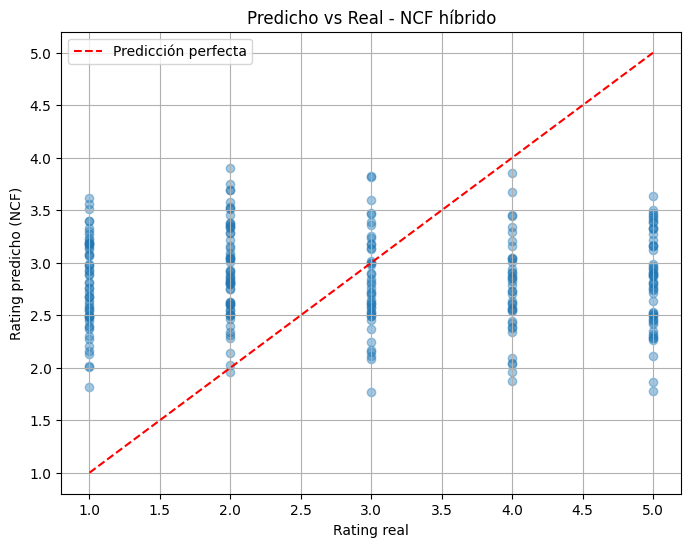

In [47]:
ncf.eval()
reales, predichos = [], []
with torch.no_grad():
    for u, i, f, r in test_loader:
        p = ncf(u.to(device), i.to(device), f.to(device)).cpu().numpy()
        predichos.extend(p)
        reales.extend(r.numpy())
reales = np.array(reales); predichos = np.array(predichos)

plt.figure(figsize=(8, 6))
plt.scatter(reales, predichos, alpha=0.4)
plt.plot([1, 5], [1, 5], "r--", label="Predicción perfecta")
plt.xlabel("Rating real"); plt.ylabel("Rating predicho (NCF)")
plt.title("Predicho vs Real - NCF híbrido")
plt.legend(); plt.grid(True); plt.show()

# Evaluación de ranking (Precision@K, Recall@K, NDCG)

Para cada interacción de test escondida, ordenamos TODOS los destinos que el usuario
no había visto en entrenamiento y verificamos si el destino correcto aparece en el
Top-K. Comparamos el NCF contra los baselines de popularidad y azar.


In [48]:
K = 5
items_train_por_usuario = train_df.groupby("u")["i"].apply(set).to_dict()
feat_por_usuario = {row["u"]: row[feat_cols].values.astype(np.float32)
                    for _, row in interacciones.drop_duplicates("u").iterrows()}
todos_los_items = np.arange(n_items)

def score_ncf(u, candidatos):
    model = ncf; model.eval()
    with torch.no_grad():
        ut = torch.tensor([u] * len(candidatos), dtype=torch.long).to(device)
        it = torch.tensor(candidatos, dtype=torch.long).to(device)
        ft = torch.tensor(np.tile(feat_por_usuario[u], (len(candidatos), 1))).to(device)
        return model(ut, it, ft).cpu().numpy()

def score_popularidad(u, candidatos):
    return popularidad_vec[candidatos]

def score_azar(u, candidatos):
    return np.random.rand(len(candidatos))

def evaluar_ranking(score_fn, K=5):
    precisiones, recalls, ndcgs = [], [], []
    for _, fila in test_df.iterrows():
        u, verdadero = int(fila["u"]), int(fila["i"])
        vistos = items_train_por_usuario.get(u, set())
        candidatos = np.array([it for it in todos_los_items if it not in vistos])
        scores = score_fn(u, candidatos)
        orden = np.argsort(-scores)
        topk = candidatos[orden[:K]]
        hit = 1 if verdadero in topk else 0
        precisiones.append(hit / K)
        recalls.append(hit)  # 1 relevante => recall = hit
        if hit:
            rank = list(topk).index(verdadero)
            ndcgs.append(1.0 / np.log2(rank + 2))
        else:
            ndcgs.append(0.0)
    return np.mean(precisiones), np.mean(recalls), np.mean(ndcgs)

p_ncf, r_ncf, n_ncf = evaluar_ranking(score_ncf, K)
p_pop, r_pop, n_pop = evaluar_ranking(score_popularidad, K)
p_rnd, r_rnd, n_rnd = evaluar_ranking(score_azar, K)

ranking = pd.DataFrame({
    "Modelo": ["NCF híbrido", "Popularidad", "Azar"],
    f"Precision@{K}": [p_ncf, p_pop, p_rnd],
    f"Recall@{K}": [r_ncf, r_pop, r_rnd],
    f"NDCG@{K}": [n_ncf, n_pop, n_rnd],
})
print(ranking.to_string(index=False))
print(f"\nNota: con ~{n_items} candidatos, el azar acierta ~{K/n_items:.4f} (Precision@{K}).")

     Modelo  Precision@5  Recall@5   NDCG@5
NCF híbrido     0.001550  0.007752 0.005545
Popularidad     0.000775  0.003876 0.001669
       Azar     0.000775  0.003876 0.001669

Nota: con ~638 candidatos, el azar acierta ~0.0078 (Precision@5).


# Matriz de confusión (recomendar / no recomendar)

Convertimos el problema a binario: un rating >= 4 se considera "destino satisfactorio
/ recomendable". Comparamos la clasificación real contra la del modelo.


Accuracy : 0.6395
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0

               precision    recall  f1-score   support

           0       0.64      1.00      0.78       165
           1       0.00      0.00      0.00        93

    accuracy                           0.64       258
   macro avg       0.32      0.50      0.39       258
weighted avg       0.41      0.64      0.50       258



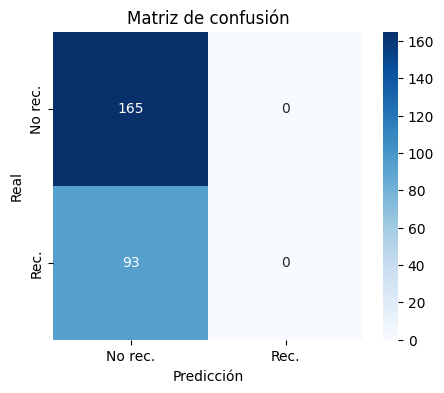

In [49]:
umbral = 4
real_bin = (reales >= umbral).astype(int)
pred_bin = (predichos >= umbral).astype(int)

print("Accuracy :", round(accuracy_score(real_bin, pred_bin), 4))
print("Precision:", round(precision_score(real_bin, pred_bin, zero_division=0), 4))
print("Recall   :", round(recall_score(real_bin, pred_bin, zero_division=0), 4))
print("F1-Score :", round(f1_score(real_bin, pred_bin, zero_division=0), 4))
print("\n", classification_report(real_bin, pred_bin, zero_division=0))

cm = confusion_matrix(real_bin, pred_bin)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No rec.", "Rec."], yticklabels=["No rec.", "Rec."])
plt.xlabel("Predicción"); plt.ylabel("Real"); plt.title("Matriz de confusión")
plt.show()

# Análisis de los embeddings de destinos

Igual que el análisis de géneros de la clase, proyectamos los embeddings de los
destinos con PCA y los caracterizamos por su Tipo.


Tamaño de la matriz de embeddings de destinos: (638, 16)


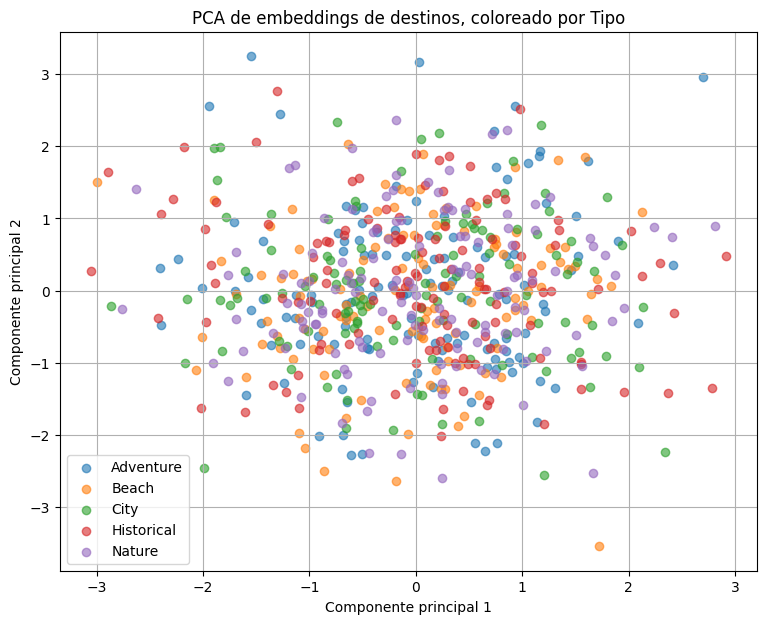

In [50]:
emb_items = ncf.item_embedding.weight.data.cpu().numpy()
print("Tamaño de la matriz de embeddings de destinos:", emb_items.shape)

pca = PCA(n_components=2)
emb_pca = pca.fit_transform(emb_items)

# Mapear cada índice de ítem -> Tipo de destino
idx_a_destid = {idx: did for idx, did in
                zip(dest_encoder.transform(dest_encoder.classes_), dest_encoder.classes_)}
destid_a_tipo = destinations_df.set_index("DestinationID")["Type"].to_dict()
tipos_items = np.array([destid_a_tipo.get(idx_a_destid[k], "Desconocido")
                        for k in range(n_items)])

plt.figure(figsize=(9, 7))
for t in np.unique(tipos_items):
    m = tipos_items == t
    plt.scatter(emb_pca[m, 0], emb_pca[m, 1], alpha=0.6, label=t)
plt.xlabel("Componente principal 1"); plt.ylabel("Componente principal 2")
plt.title("PCA de embeddings de destinos, coloreado por Tipo")
plt.legend(); plt.grid(True); plt.show()

## Caracterización de cada tipo por su embedding medio y similitud


Similitud coseno entre tipos de destino:
            Adventure  Beach   City  Historical  Nature
Adventure       1.000 -0.002 -0.105       0.107  -0.116
Beach          -0.002  1.000  0.614      -0.138  -0.259
City           -0.105  0.614  1.000      -0.228   0.064
Historical      0.107 -0.138 -0.228       1.000   0.005
Nature         -0.116 -0.259  0.064       0.005   1.000


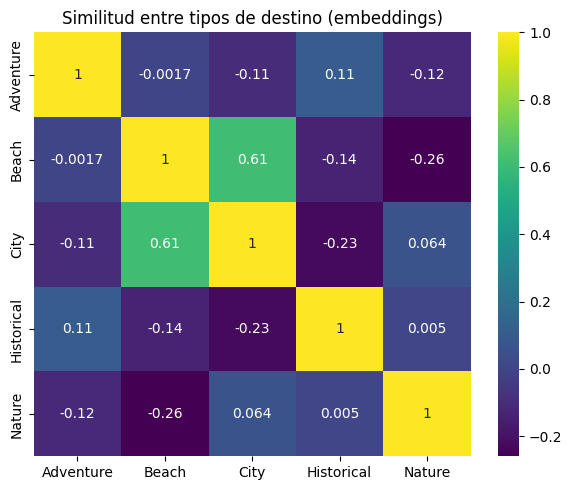

In [51]:
"""## Caracterización de cada tipo por su embedding medio y similitud"""
tipos_unicos = sorted(set(destid_a_tipo.values()))
medias = {}
for t in tipos_unicos:
    m = tipos_items == t
    if m.sum() > 0:
        medias[t] = emb_items[m].mean(axis=0)

nombres_tipo = list(medias.keys())
matriz_emb = np.array([medias[t] for t in nombres_tipo])
sim = cosine_similarity(matriz_emb)
sim_df = pd.DataFrame(sim, index=nombres_tipo, columns=nombres_tipo)
print("Similitud coseno entre tipos de destino:")
print(sim_df.round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(sim_df, annot=True, cmap="viridis")
plt.title("Similitud entre tipos de destino (embeddings)")
plt.tight_layout(); plt.show()



## Clustering jerárquico de los tipos de destino


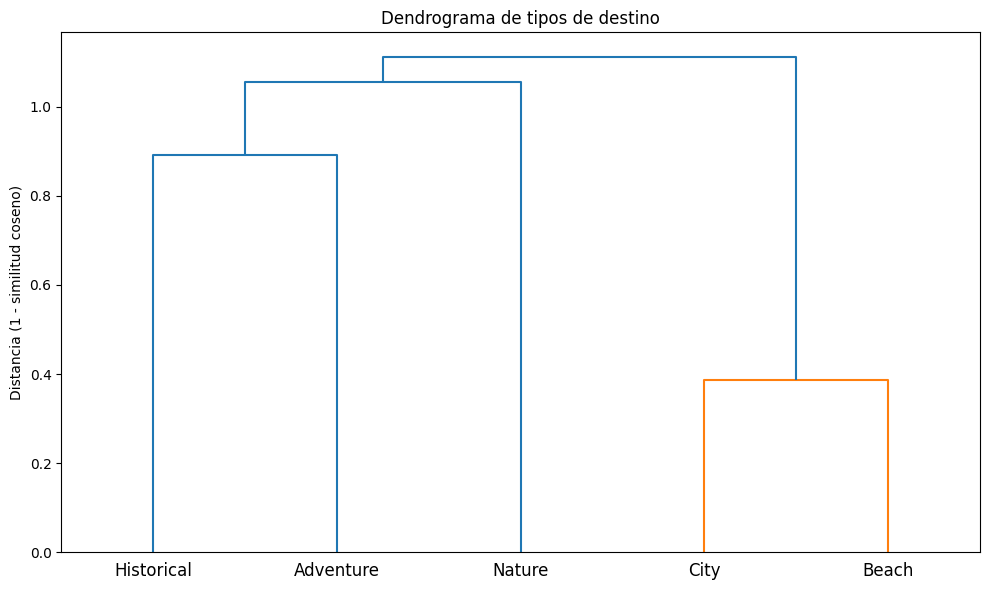

In [52]:
"""## Clustering jerárquico de los tipos de destino"""
dist = 1 - sim
np.fill_diagonal(dist, 0)
condensada = squareform(dist, checks=False)
enlace = linkage(condensada, method="average")

plt.figure(figsize=(10, 6))
dendrogram(enlace, labels=nombres_tipo, distance_sort="descending")
plt.title("Dendrograma de tipos de destino")
plt.ylabel("Distancia (1 - similitud coseno)")
plt.tight_layout(); plt.show()

# Sistema de recomendación híbrido (con componente de contenido)

Dado que la señal colaborativa es nula, el componente que genera recomendaciones
ÚTILES e interpretables es el basado en contenido: recomienda destinos cuyo Tipo
coincide con las preferencias del usuario, ordenados por popularidad. El score final
combina el modelo neuronal con el contenido.


In [53]:
pop_norm = (destinations_df.set_index("DestinationID")["Popularity"]
            - destinations_df["Popularity"].min()) / \
           (destinations_df["Popularity"].max() - destinations_df["Popularity"].min())
pop_norm = pop_norm.to_dict()

def tipos_preferidos(user_id):
    fila = users_df[users_df["UserID"] == user_id]
    if len(fila) == 0:
        return set()
    prefs = fila.iloc[0]["PrefList"]
    return {pref_a_tipo.get(p) for p in prefs}

def recomendar_contenido(user_id, top_k=5):
    """Recomendación basada en contenido: tipo preferido + popularidad."""
    tipos = tipos_preferidos(user_id)
    cand = destinations_df.copy()
    cand["match"] = cand["Type"].isin(tipos).astype(int)
    cand["pop_norm"] = cand["DestinationID"].map(pop_norm)
    cand["score"] = cand["match"] * 2 + cand["pop_norm"]
    cand = cand.sort_values("score", ascending=False).head(top_k)
    return cand[["DestinationID", "Name", "State", "Type", "Popularity"]]

print("Ejemplo: recomendaciones basadas en contenido para el usuario 2")
print("Preferencias:", users_df[users_df.UserID == 2].iloc[0]["Preferences"])
print(recomendar_contenido(2, top_k=5).to_string(index=False))


Ejemplo: recomendaciones basadas en contenido para el usuario 2
Preferencias: Nature, Adventure
 DestinationID              Name             State      Type  Popularity
            59 Kerala Backwaters            Kerala    Nature    9.490123
           154 Kerala Backwaters            Kerala    Nature    9.484798
           515        Leh Ladakh Jammu and Kashmir Adventure    9.481319
           114 Kerala Backwaters            Kerala    Nature    9.467147
           684 Kerala Backwaters            Kerala    Nature    9.465996


# Cold-start: recomendar a un usuario NUEVO (actividad 3 de clase)

Un usuario nuevo no tiene embedding entrenado, pero sí datos demográficos y
preferencias. El sistema recurre al componente de contenido.


In [54]:
def recomendar_usuario_nuevo(preferencias, top_k=5):
    tipos = {pref_a_tipo.get(p.strip()) for p in preferencias.split(",")}
    cand = destinations_df.copy()
    cand["match"] = cand["Type"].isin(tipos).astype(int)
    cand["pop_norm"] = cand["DestinationID"].map(pop_norm)
    cand["score"] = cand["match"] * 2 + cand["pop_norm"]
    cand = cand.sort_values("score", ascending=False).head(top_k)
    return cand[["DestinationID", "Name", "State", "Type", "Popularity"]]

print("Usuario nuevo con preferencias 'Beaches, Adventure':")
print(recomendar_usuario_nuevo("Beaches, Adventure", top_k=5).to_string(index=False))

Usuario nuevo con preferencias 'Beaches, Adventure':
 DestinationID        Name             State      Type  Popularity
           987 Goa Beaches               Goa     Beach    9.499811
            72 Goa Beaches               Goa     Beach    9.498129
           837 Goa Beaches               Goa     Beach    9.492706
           172 Goa Beaches               Goa     Beach    9.486280
           515  Leh Ladakh Jammu and Kashmir Adventure    9.481319


# Recomendar un destino NUEVO a usuarios existentes (actividad 4 de clase)

Un destino nuevo no tiene embedding, pero conocemos su Tipo. Lo recomendamos a los
usuarios cuyas preferencias coinciden con ese tipo.


In [55]:
def usuarios_para_destino_nuevo(tipo_destino, top_k=10):
    objetivo = {p for p, t in pref_a_tipo.items() if t == tipo_destino}
    coincidentes = users_df[users_df["PrefList"].apply(
        lambda L: len(set(L) & objetivo) > 0)]
    return coincidentes[["UserID", "Name", "Preferences"]].head(top_k)

print("Usuarios candidatos para un destino nuevo de tipo 'Nature':")
print(usuarios_para_destino_nuevo("Nature", top_k=10).to_string(index=False))

Usuarios candidatos para un destino nuevo de tipo 'Nature':
 UserID   Name       Preferences
      2  Rohan Nature, Adventure
      5  Tanvi Nature, Adventure
      8 Vivaan Nature, Adventure
     11 Vivaan Nature, Adventure
     14  Meera Nature, Adventure
     17  Aanya Nature, Adventure
     20  Meera Nature, Adventure
     23  Arjun Nature, Adventure
     26  Dhruv Nature, Adventure
     29   Diya Nature, Adventure


# Guardar el modelo y las métricas


In [56]:
"""# Guardar el modelo y las métricas"""
torch.save(ncf.state_dict(), "ncf_hibrido_destinos.pth")

metricas = pd.DataFrame({
    "Metrica": ["RMSE_baseline_media", "RMSE_NCF", "RMSE_MF",
                f"Precision@{K}_NCF", f"Precision@{K}_Popularidad", f"Precision@{K}_Azar",
                f"Recall@{K}_NCF", f"NDCG@{K}_NCF",
                "Accuracy_bin", "F1_bin"],
    "Valor": [rmse_media, best_ncf, best_mf,
              p_ncf, p_pop, p_rnd, r_ncf, n_ncf,
              accuracy_score(real_bin, pred_bin),
              f1_score(real_bin, pred_bin, zero_division=0)]
})
metricas.to_csv("metricas_recomendacion.csv", index=False)
print(metricas.to_string(index=False))
print("\nModelo y métricas guardados.")



                Metrica    Valor
    RMSE_baseline_media 1.449971
               RMSE_NCF 1.528349
                RMSE_MF 1.706527
        Precision@5_NCF 0.001550
Precision@5_Popularidad 0.000775
       Precision@5_Azar 0.000775
           Recall@5_NCF 0.007752
             NDCG@5_NCF 0.005545
           Accuracy_bin 0.639535
                 F1_bin 0.000000

Modelo y métricas guardados.


# Conclusiones — Análisis de efectividad

1. Ausencia de señal demostrada por múltiples vías. Ni el NCF, ni la factorización de matrices, ni la reagrupación por persona, ni la consolidación de destinos superan sus respectivos baselines. La conclusión es estructural del dataset, no una limitación de la implementación.

2. Aplicación honesta de Deep Learning. El sistema implementa correctamente la arquitectura NCF, la evalúa con leave-one-out y baselines, y controla el sobreajuste con dropout, regularización L2 y early stopping. El valor del módulo reside en la corrección metodológica y en diagnosticar los datos antes de confiar en las métricas.

2. Recomendaciones útiles vía contenido. El componente basado en contenido genera recomendaciones coherentes e interpretables y resuelve el cold-start; es la parte del sistema directamente aplicable a las rutas de la empresa.

3. Condición para valor en producción. Para que el componente colaborativo aporte, se requieren datos reales con suficientes interacciones genuinas por usuario y una relación auténtica entre preferencias, comportamiento y satisfacción. Bajo esas condiciones, las transformaciones exploradas (consolidación, integración de reviews, estacionalidad) sí podrían contribuir.

